# Backtesting Trimestral 2025 — Reversión a la Media / RNN-GRU


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches

# Añadimos project root, model/cnn y scripts al path
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]
SCRIPTS_DIR = NOTEBOOK_DIR.parent / "scripts"

for _p in [str(PROJECT_ROOT), str(PROJECT_ROOT / "model" / "cnn"), str(SCRIPTS_DIR)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import backtest_quarterly_reversion as bt

bt.setup(model_type="gru", input_window=10, output_window=90)


Modelo cargado: data/rnn/saved_models/rnn_gru_input10_output90_model.keras
GRU: sin escalado de inputs.
Universo: 23 activos | 2025: 2025-01-02 → 2025-12-31 (250 días)
Periodos de rebalanceo (4):
  Q1: 2025-01-02 → 2025-03-31
  Q2: 2025-04-01 → 2025-06-30
  Q3: 2025-07-01 → 2025-09-30
  Q4: 2025-10-01 → 2025-12-31


## 1. Universo de activos


In [2]:
returns_2025 = bt.returns_full.loc["2025"]

print(f"Periodo out-of-sample : {returns_2025.index[0].date()} → {returns_2025.index[-1].date()}")
print(f"Días de trading       : {len(returns_2025)}")
print()
print(f"Activos ({bt.n_assets}):")
print(bt.assets)

# Estadísticas de retorno diario en porcentaje
stats = (returns_2025.describe().T[["mean", "std", "min", "max"]] * 100).round(4)
stats.columns = ["Media diaria (%)", "Vol. diaria (%)", "Mínimo (%)", "Máximo (%)"]
display(stats.sort_values("Media diaria (%)", ascending=False))


Periodo out-of-sample : 2025-01-02 → 2025-12-31
Días de trading       : 250

Activos (23):
['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


,Media diaria (%),Vol. diaria (%),Mínimo (%),Máximo (%)
Ticker,,,,
GE,0.2477,1.9178,-11.7617,10.0466
CAT,0.1888,2.0022,-9.0315,11.0061
JNJ,0.1554,1.2355,-7.8953,6.0090
IBM,0.1295,1.8824,-7.9301,12.1900
GD,0.1062,1.3355,-7.5513,6.5128
AEP,0.1030,1.2192,-4.3361,5.9034
MMM,0.0936,1.8608,-9.6305,8.4124
CNP,0.0852,1.0415,-3.4862,2.8763
BA,0.0817,2.3586,-11.0608,14.3010


## 2. Señal de reversión a la media en cada rebalanceo


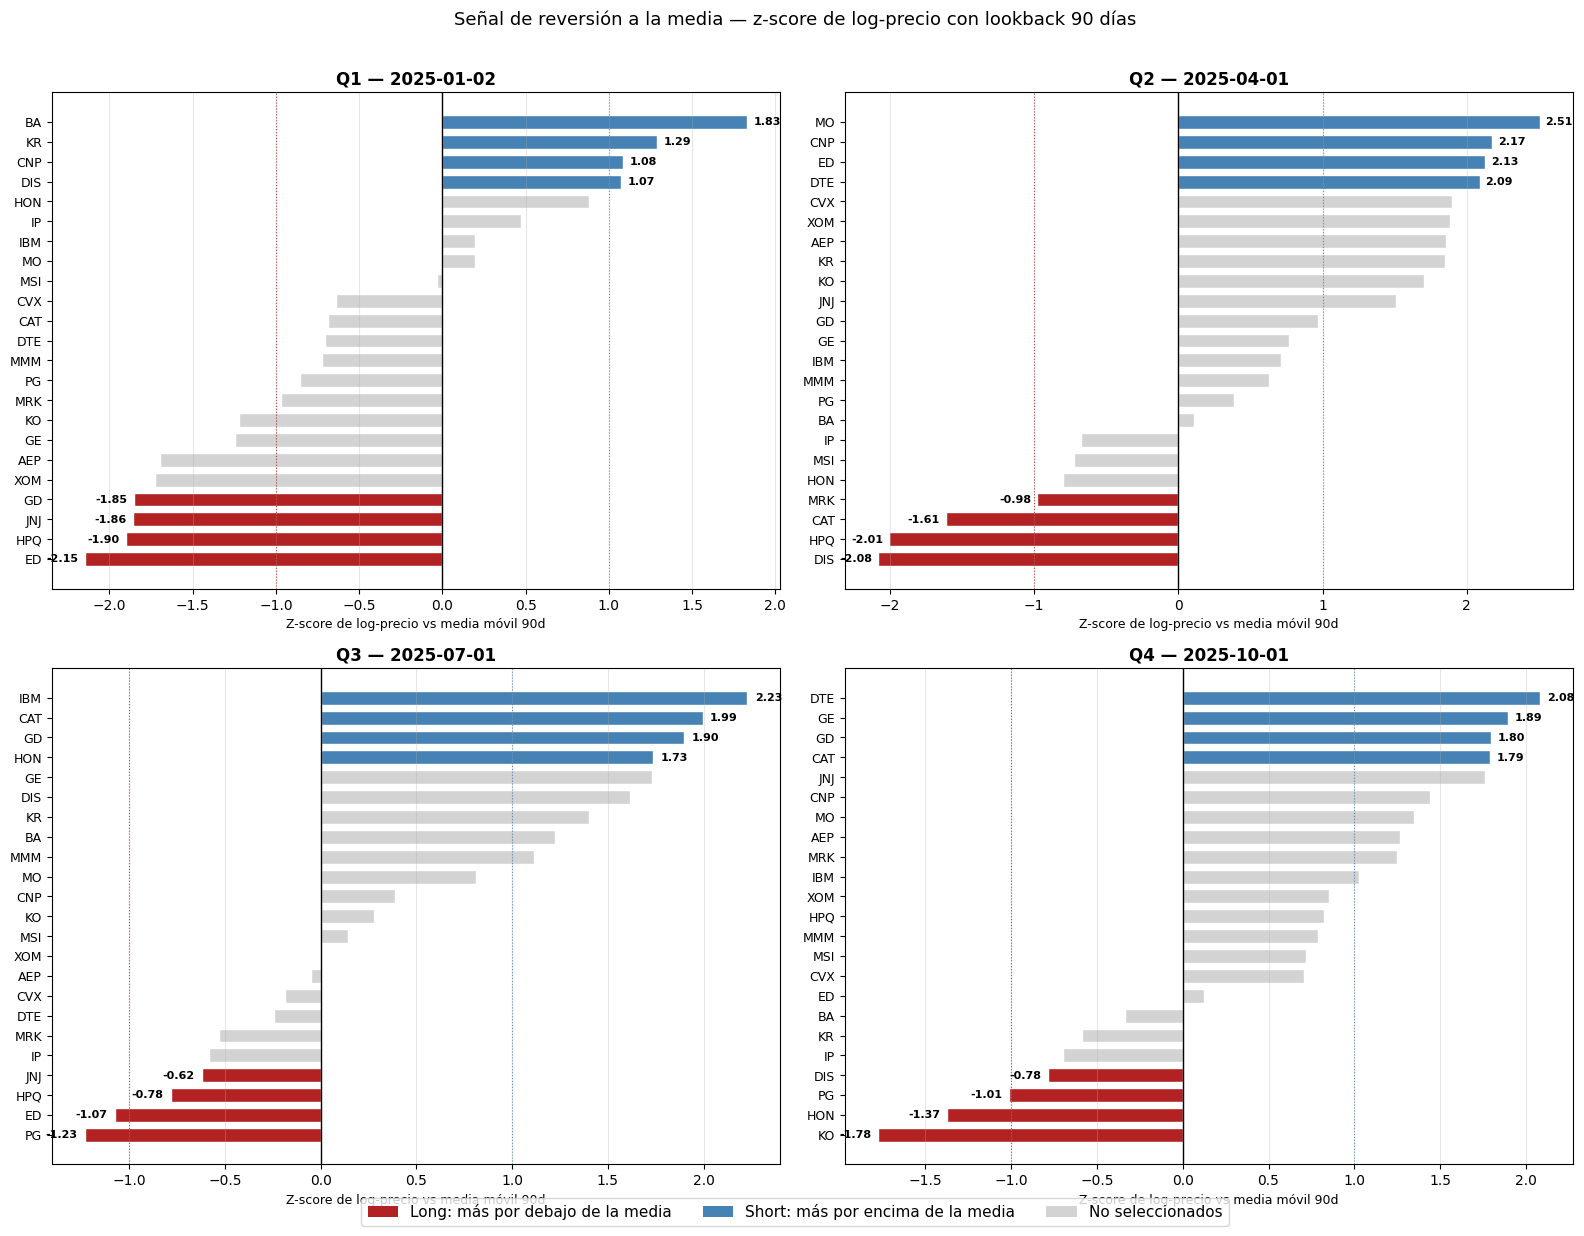

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for q_idx, (rb_date, ax) in enumerate(zip(bt.rebalance_dates, axes)):
    z = bt.mean_reversion_zscore(rb_date, bt.TRAILING_VOL_DAYS)
    bottom4_idx = set(int(i) for i in np.argsort(z.values)[:bt.N_TOP])
    top4_idx = set(int(i) for i in np.argsort(z.values)[-bt.N_TOP:])
    order = list(np.argsort(z.values))

    sorted_assets = [bt.assets[j] for j in order]
    z_values = [float(z.iloc[j]) for j in order]
    colors = [
        "firebrick" if j in bottom4_idx else "steelblue" if j in top4_idx else "lightgray"
        for j in order
    ]

    bars = ax.barh(sorted_assets, z_values, color=colors, edgecolor="white", height=0.7)
    ax.axvline(0, color="black", lw=1)
    ax.axvline(-1, color="firebrick", lw=0.8, ls=":", alpha=0.8)
    ax.axvline(1, color="steelblue", lw=0.8, ls=":", alpha=0.8)
    ax.set_title(f"Q{q_idx + 1} — {rb_date.strftime('%Y-%m-%d')}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Z-score de log-precio vs media móvil 90d", fontsize=9)
    ax.grid(True, alpha=0.3, axis="x")
    ax.tick_params(axis="y", labelsize=9)

    for bar, val, j in zip(bars, z_values, order):
        if j in bottom4_idx or j in top4_idx:
            x = val + (0.04 if val >= 0 else -0.04)
            ha = "left" if val >= 0 else "right"
            ax.text(
                x, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", ha=ha, fontsize=8, fontweight="bold",
            )

legend_elems = [
    mpatches.Patch(facecolor="firebrick", label="Long: más por debajo de la media"),
    mpatches.Patch(facecolor="steelblue", label="Short: más por encima de la media"),
    mpatches.Patch(facecolor="lightgray", label="No seleccionados"),
]
fig.legend(handles=legend_elems, loc="lower center", ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(
    "Señal de reversión a la media — z-score de log-precio con lookback 90 días",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()


## 3. Ejecución del backtest


In [4]:
ret_df, holdings = bt.run_backtest()

MODEL_LABEL = bt.MODEL_TYPE.upper() + (" Rel" if bt.RELATIVE and bt.MODEL_TYPE == "cnn" else "")

LABELS = {
    "model_top4_equal":             f"{MODEL_LABEL} Equal",
    "model_top4_riskadjusted":      f"{MODEL_LABEL} Risk-Adj.",
    "model_top4_threshold":         f"{MODEL_LABEL} Umbral",
    "model_top4_propweights":       f"{MODEL_LABEL} Prop.",
    "model_longshort":              f"{MODEL_LABEL} Long-Short",
    "bench_reversion_zscore_90d":   "Reversión z-score 90d",
    "bench_reversion_zscore_input": f"Reversión z-score {bt.INPUT_WINDOW}d",
    "bench_reversion_longshort":    "Reversión Long-Short",
    "bench_equalweight":            "Equal Weight",
}


def format_weights(strategy_name, rb_date):
    pred = bt.predict_at(rb_date)
    vol = bt.trailing_vol(rb_date)
    weights = bt.STRATEGIES[strategy_name](pred=pred, vol=vol, date=rb_date)
    if strategy_name == "bench_equalweight":
        return f"todos (1/{bt.n_assets})"
    if not weights:
        return "cash"
    longs = sorted([asset for asset, weight in weights.items() if weight > 0])
    shorts = sorted([asset for asset, weight in weights.items() if weight < 0])
    if shorts:
        return f"L: {', '.join(longs)} | S: {', '.join(shorts)}"
    return ", ".join(longs)


quarter_names = [f"Q{i+1} ({d.strftime('%b %Y')})" for i, d in enumerate(bt.rebalance_dates)]
rows = {}
for name, label in LABELS.items():
    rows[label] = [format_weights(name, rb_date) for rb_date in bt.rebalance_dates]

sel_df = pd.DataFrame(rows, index=quarter_names).T
display(sel_df)


Q1 (2025-01-02): pred top-4 = ['MO', 'DTE', 'HPQ', 'JNJ']
Q2 (2025-04-01): pred top-4 = ['MSI', 'MO', 'HPQ', 'HON']
Q3 (2025-07-01): pred top-4 = ['MO', 'HPQ', 'GD', 'JNJ']
Q4 (2025-10-01): pred top-4 = ['MSI', 'MO', 'HPQ', 'DTE']


,Q1 (Jan 2025),Q2 (Apr 2025),Q3 (Jul 2025),Q4 (Oct 2025)
GRU Equal,"DTE, HPQ, JNJ, MO","HON, HPQ, MO, MSI","GD, HPQ, JNJ, MO","DTE, HPQ, MO, MSI"
GRU Risk-Adj.,"DTE, JNJ, MO, MSI","DTE, JNJ, MO, MSI","CNP, DTE, JNJ, MO","CNP, DTE, MO, MSI"
GRU Umbral,"DTE, HPQ, JNJ, MO","HON, HPQ, MO, MSI","GD, HPQ, JNJ, MO","DTE, HPQ, MO, MSI"
GRU Prop.,"DTE, HPQ, JNJ, MO","HON, HPQ, MO, MSI","GD, HPQ, JNJ, MO","DTE, HPQ, MO, MSI"
GRU Long-Short,"L: DTE, HPQ, JNJ, MO | S: AEP, DIS, IBM, KO","L: HON, HPQ, MO, MSI | S: AEP, BA, IBM, MRK","L: GD, HPQ, JNJ, MO | S: AEP, GE, IBM, IP","L: DTE, HPQ, MO, MSI | S: AEP, CVX, IBM, MMM"
Reversión z-score 90d,"ED, GD, HPQ, JNJ","CAT, DIS, HPQ, MRK","ED, HPQ, JNJ, PG","DIS, HON, KO, PG"
Reversión z-score 10d,"HON, IBM, MSI, PG","CAT, GE, HPQ, MMM","CVX, MO, MRK, XOM","CVX, HPQ, MSI, XOM"
Reversión Long-Short,"L: ED, GD, HPQ, JNJ | S: BA, CNP, DIS, KR","L: CAT, DIS, HPQ, MRK | S: CNP, DTE, ED, MO","L: ED, HPQ, JNJ, PG | S: CAT, GD, HON, IBM","L: DIS, HON, KO, PG | S: CAT, DTE, GD, GE"
Equal Weight,todos (1/23),todos (1/23),todos (1/23),todos (1/23)


## 4. Retorno acumulado


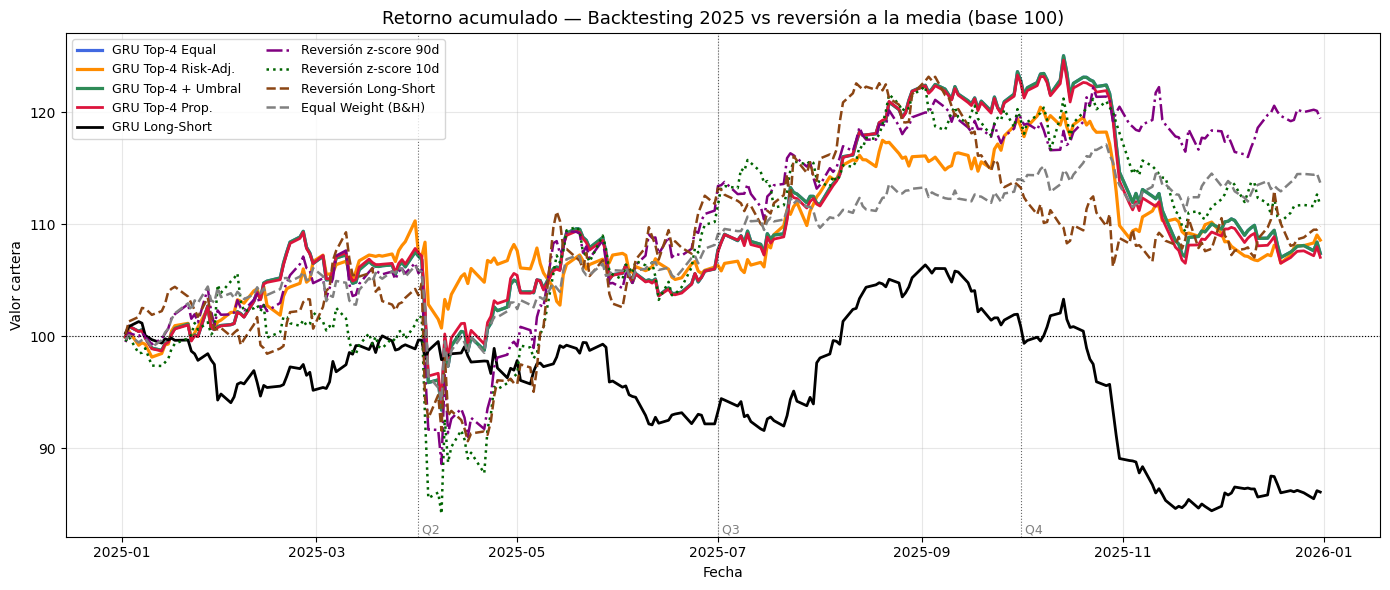

Retorno final (base 100):
  GRU Top-4 Equal                   : 107.41  (+7.41 %)
  GRU Top-4 Risk-Adj.               : 108.59  (+8.59 %)
  GRU Top-4 + Umbral                : 107.41  (+7.41 %)
  GRU Top-4 Prop.                   : 107.06  (+7.06 %)
  GRU Long-Short                    : 86.09  (-13.91 %)
  Reversión z-score 90d             : 119.46  (+19.46 %)
  Reversión z-score 10d             : 111.72  (+11.72 %)
  Reversión Long-Short              : 109.84  (+9.84 %)
  Equal Weight (B&H)                : 113.73  (+13.73 %)


In [5]:
cum_value = ret_df.cumsum().apply(np.exp) * 100

STYLE = {
    "model_top4_equal":             dict(color="royalblue",   lw=2.3, ls="-",  label=f"{MODEL_LABEL} Top-4 Equal"),
    "model_top4_riskadjusted":      dict(color="darkorange",  lw=2.3, ls="-",  label=f"{MODEL_LABEL} Top-4 Risk-Adj."),
    "model_top4_threshold":         dict(color="seagreen",    lw=2.3, ls="-",  label=f"{MODEL_LABEL} Top-4 + Umbral"),
    "model_top4_propweights":       dict(color="crimson",     lw=2.0, ls="-",  label=f"{MODEL_LABEL} Top-4 Prop."),
    "model_longshort":              dict(color="black",       lw=2.0, ls="-",  label=f"{MODEL_LABEL} Long-Short"),
    "bench_reversion_zscore_90d":   dict(color="purple",      lw=1.8, ls="-.", label="Reversión z-score 90d"),
    "bench_reversion_zscore_input": dict(color="darkgreen",   lw=1.8, ls=":",  label=f"Reversión z-score {bt.INPUT_WINDOW}d"),
    "bench_reversion_longshort":    dict(color="saddlebrown", lw=1.8, ls="--", label="Reversión Long-Short"),
    "bench_equalweight":            dict(color="gray",        lw=1.8, ls="--", label="Equal Weight (B&H)"),
}

fig, ax = plt.subplots(figsize=(14, 6))
for name, style in STYLE.items():
    ax.plot(cum_value.index, cum_value[name], **style)

for i, rb in enumerate(bt.rebalance_dates[1:], start=2):
    ax.axvline(rb, color="black", lw=0.8, ls=":", alpha=0.6)
    ax.text(rb, ax.get_ylim()[0], f" Q{i}", fontsize=9, color="gray", va="bottom")

ax.axhline(100, color="black", lw=0.8, ls=":")
ax.set_title("Retorno acumulado — Backtesting 2025 vs reversión a la media (base 100)", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor cartera")
ax.legend(fontsize=9, loc="upper left", ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Retorno final (base 100):")
for name, style in STYLE.items():
    final = float(cum_value[name].iloc[-1])
    print(f"  {style['label']:34s}: {final:.2f}  ({final - 100:+.2f} %)")


## 5. Métricas de rendimiento


,Retorno (%),Sharpe,Max DD (%),Turnover
GRU Equal,7.41,0.186,-14.60,1.000
GRU Risk-Adj.,8.59,0.309,-11.56,0.333
GRU Umbral,7.41,0.186,-14.60,1.000
GRU Prop.,7.06,0.169,-14.55,1.000
GRU Long-Short,-13.91,-1.372,-20.65,2.000
Reversión z-score 90d,19.46,0.641,-17.72,1.500
Reversión z-score 10d,11.72,0.304,-20.33,1.667
Reversión Long-Short,9.84,0.223,-17.08,2.167
Equal Weight,13.73,0.653,-11.33,0.000


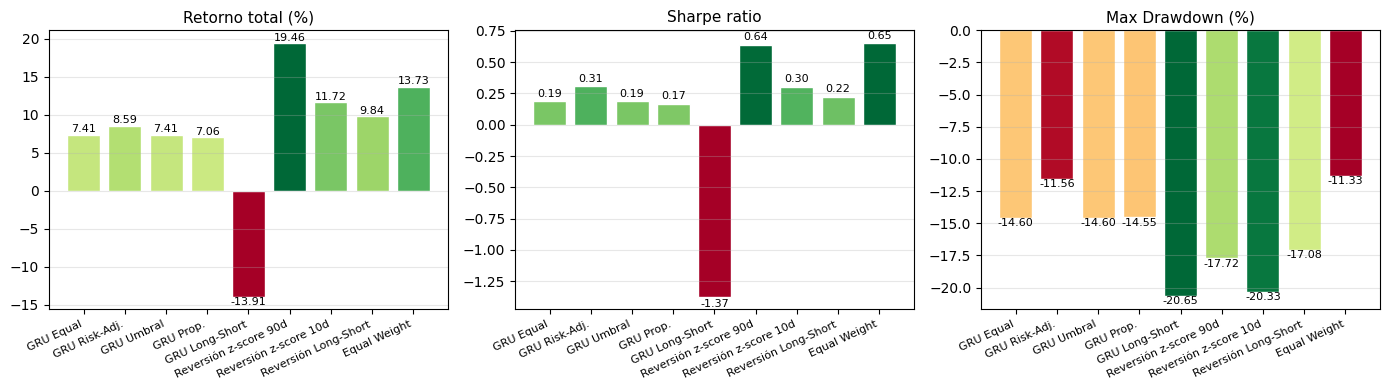

In [6]:
metrics_rows = [bt.compute_metrics(n, ret_df, holdings) for n in bt.STRATEGIES]
metrics = pd.DataFrame(metrics_rows).set_index("strategy")
metrics.index = [LABELS.get(n, n) for n in metrics.index]
metrics.columns = ["Retorno (%)", "Sharpe", "Max DD (%)", "Turnover"]

display(
    metrics.style
    .format({"Retorno (%)": "{:.2f}", "Sharpe": "{:.3f}", "Max DD (%)": "{:.2f}", "Turnover": "{:.3f}"})
    .background_gradient(subset=["Retorno (%)"], cmap="RdYlGn")
    .background_gradient(subset=["Sharpe"],      cmap="RdYlGn")
    .background_gradient(subset=["Max DD (%)"],  cmap="RdYlGn_r")
    .set_caption("Métricas de backtesting 2025")
)

# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cols   = ["Retorno (%)", "Sharpe", "Max DD (%)"]
cmaps  = ["RdYlGn", "RdYlGn", "RdYlGn_r"]
titles = ["Retorno total (%)", "Sharpe ratio", "Max Drawdown (%)"]

for ax, col, cmap_name, title in zip(axes, cols, cmaps, titles):
    vals   = metrics[col]
    cmap   = plt.get_cmap(cmap_name)
    norm   = plt.Normalize(vals.min(), vals.max())
    colors = [cmap(norm(v)) for v in vals]
    bars   = ax.bar(range(len(vals)), vals, color=colors, edgecolor="white")
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=25, ha="right", fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")
    for bar, v in zip(bars, vals):
        offset = 0.02 if v >= 0 else -0.02
        va = "bottom" if v >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
                f"{v:.2f}", ha="center", va=va, fontsize=8)

plt.tight_layout()
plt.show()


## 6. Análisis de drawdown


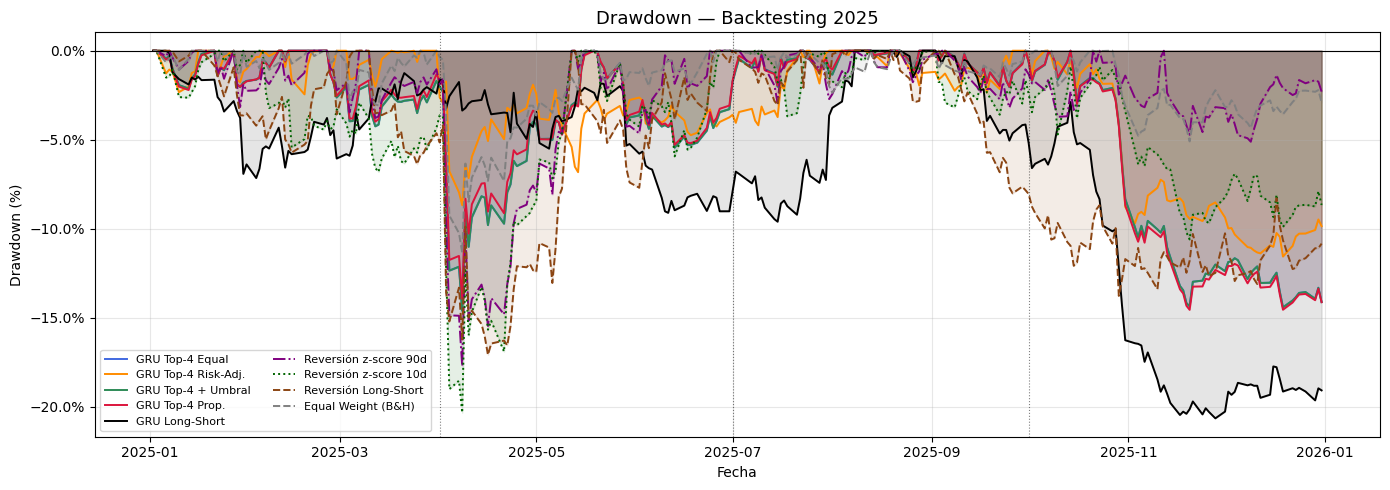

Max Drawdown por estrategia:
  GRU Top-4 Equal                   : -14.60 %
  GRU Top-4 Risk-Adj.               : -11.56 %
  GRU Top-4 + Umbral                : -14.60 %
  GRU Top-4 Prop.                   : -14.55 %
  GRU Long-Short                    : -20.65 %
  Reversión z-score 90d             : -17.72 %
  Reversión z-score 10d             : -20.33 %
  Reversión Long-Short              : -17.08 %
  Equal Weight (B&H)                : -11.33 %


In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

for name, style in STYLE.items():
    cum = ret_df[name].cumsum().apply(np.exp)
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax.fill_between(dd.index, dd, 0, alpha=0.10, color=style["color"])
    ax.plot(dd.index, dd, lw=1.4, color=style["color"], ls=style["ls"], label=style["label"])

for rb in bt.rebalance_dates[1:]:
    ax.axvline(rb, color="black", lw=0.8, ls=":", alpha=0.5)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Drawdown — Backtesting 2025", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=1))
ax.legend(fontsize=8, loc="lower left", ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Max Drawdown por estrategia:")
for name, style in STYLE.items():
    cum = ret_df[name].cumsum().apply(np.exp)
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    print(f"  {style['label']:34s}: {float(dd.min()):.2f} %")


## 7. Interpretación de la reversión a la media

La señal de reversión se calcula con el z-score del log-precio respecto a su media móvil previa, sin usar retornos futuros. Un z-score negativo indica que el activo está por debajo de su media reciente; las variantes long-only compran los valores más alejados por debajo de esa media.

La variante `bench_reversion_zscore_90d` usa una ventana fija de 90 sesiones para capturar desviaciones más estables. `bench_reversion_zscore_input` usa la misma ventana de entrada que el modelo, por lo que compara contra un benchmark clásico con el mismo conjunto de información temporal. `bench_reversion_longshort` añade una pata corta en los activos más alejados por encima de su media, con exposición neta aproximada a cero.
